In [1]:
import numpy as np
import pandas as pd
import os
import random
import json
from collections import defaultdict
from itertools import chain

# scikit-learn 相关
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix,
                            accuracy_score, roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.model_selection import learning_curve

from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.base import clone
# 可视化相关
import matplotlib.pyplot as plt
import seaborn as sns

# 设置全局随机种子
np.random.seed(11)
random.seed(11)
os.environ['PYTHONHASHSEED'] = str(11)

# 其他库（如果适用，请取消注释）
# import tensorflow as tf
# tf.random.set_seed(11)
# import torch
# torch.manual_seed(11)

# 加载与保存模型等操作
import pickle
#import torch

import xgboost as xgb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import math

In [11]:
input_dir = "/mnt/f/精浆文章/20250310/"
output_dir = "/mnt/f/精浆文章/20250310/num_article/"
#if not exists  create output_dir
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
#set working directory
os.chdir(output_dir)



In [12]:
clin=pd.read_csv(input_dir+"clin.txt",index_col=0,sep="\t")
print(clin)
mlnc_expression=pd.read_csv(input_dir+"Genes_TPM.txt",index_col=0,sep="\t")
print(mlnc_expression)

               num  num_group    PR  PR_NP  PR_NP_group  PR_group
samplename                                                       
CF-N007      749.3          0  87.0   89.6            0         0
CF-N012     1237.0          0  45.0   51.6            0         0
CF-N018      197.2          0  33.5   34.6            1         0
CF-N027      361.3          0  42.9   45.7            0         0
CF-N031      120.3          0  55.0   59.3            0         0
...            ...        ...   ...    ...          ...       ...
CF-W127        0.0          1   0.0    0.0            1         1
CF-W128        0.0          1   0.0    0.0            1         1
CF-W129        0.0          1   0.0    0.0            1         1
CF-W130        0.0          1   0.0    0.0            1         1
CF-W131        0.0          1   0.0    0.0            1         1

[431 rows x 6 columns]
              CF-N007  CF-N012  CF-N018  CF-N027  CF-N031  CF-N032  CF-N034  \
Gene                                   

In [13]:
feature_selection=pd.read_csv(input_dir+"num_feature.txt",sep="\t",header=None)
feature_selection = feature_selection[0].tolist()
feature_selection[0:5]

['EIF1AX-AS1', 'SPATA42', 'MAP3K4', 'RND3', 'ENSG00000286283']

In [14]:
#col num_group = 0 or 1 
clin = clin[clin["num_group"].isin([0,1])]
usesamplename=list(mlnc_expression.columns.intersection(clin.index))
#use usesamplename to select mlnc_expression columns
mlnc_expression_use=mlnc_expression[usesamplename]
#use usesamplename to select clin rows
clin_use=clin.loc[usesamplename]

#filter rowname feature_selection
mlnc_expression_use = mlnc_expression_use.loc[feature_selection]
mlnc_expression_use

,CF-N007,CF-N012,CF-N018,CF-N027,CF-N031,CF-N032,CF-N034,CF-N035,CF-N036,CF-N038,...,CF-W120,CF-W121,CF-W122,CF-W123,CF-W124,CF-W127,CF-W128,CF-W129,CF-W130,CF-W131
Gene,,,,,,,,,,,,,,,,,,,,,
EIF1AX-AS1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
SPATA42,56.03,145.45,34.56,11.93,42.15,32.48,47.57,17.27,152.10,43.64,...,0.02,0.00,0.00,0.00,2.73,0.87,0.00,0.72,3.18,0.50
MAP3K4,41.91,37.82,35.54,25.15,29.05,24.23,26.79,43.72,17.75,89.11,...,29.62,56.34,21.42,21.22,21.45,21.20,33.53,23.83,19.46,26.87
RND3,1.09,0.97,0.35,0.49,0.95,1.48,0.33,0.57,1.44,1.01,...,1.19,1.32,0.62,0.78,0.15,0.77,1.13,1.41,0.11,1.60
ENSG00000286283,0.00,0.39,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000237015,0.00,0.00,2.17,0.00,2.20,0.00,0.45,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
KCNJ4,0.00,0.00,0.00,0.06,0.00,0.00,0.21,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.00,0.00
ENSG00000289581,0.00,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.07,...,0.07,0.00,0.04,0.00,0.00,0.00,0.06,0.00,0.00,0.00


In [15]:
detected_in_samples = np.sum(mlnc_expression_use > 0, axis=1)
detected_in_samples

Gene
EIF1AX-AS1           1
SPATA42            348
MAP3K4             421
RND3               420
ENSG00000286283     11
                  ... 
ENSG00000237015    118
KCNJ4               31
ENSG00000289581    160
OR2T12             360
ENSG00000287698    176
Length: 417, dtype: int64

In [16]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

import numpy as np
import pandas as pd
#preprocessing
from sklearn import preprocessing
#LinearRegression
from sklearn.linear_model import LinearRegression
# mean_squared_error and mean_absolute_error and r2_score 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [17]:
mlnc_expression_use_filtered=mlnc_expression_use
X=mlnc_expression_use_filtered.T
y=clin_use["num"]
name = "num"
Y = y
X = np.asarray(X)
X = np.nan_to_num(X)
y = np.asarray(Y)
min_max_scaler = preprocessing.MinMaxScaler()
X = min_max_scaler.fit_transform(X)
X = np.asarray(X,dtype=np.float32)

In [18]:


kf = KFold(n_splits=10, shuffle=True, random_state=42)
#kf = KFold(n_splits=10, shuffle=True)
results = {
    'Fold': [],
    'R2': [],
    'Pearson pvalue': [],
    'Pearson correlation': [],
    'RMSE': [],
    'MSE': []
}


overall_predictions = np.zeros_like(y)

fold = 1
for train_index, test_index in kf.split(X):
    print(f'Fold {fold}')
    #print('Training samples:', train_index)
    #X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    #sc = StandardScaler() 
    #sc.fit(X_train) 
    #X_train = sc.transform(X_train) 
    #X_test = sc.transform(X_test) 
    
    #model = SVR()
    model  = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mse = mean_squared_error(y_test, y_pred)
    correlation, p_value = pearsonr(y_test, y_pred)
    
    results['Fold'].append(fold)
    results['R2'].append(r2)
    results['Pearson pvalue'].append(p_value)
    results['Pearson correlation'].append(correlation)
    results['RMSE'].append(rmse)
    results['MSE'].append(mse)
    
    
    overall_predictions[test_index] = y_pred
    fold += 1

results_df = pd.DataFrame(results)
results_df.to_csv(name+'_cross_validation_results.csv', index=False)

# 计算整体样本的R2、p值和RMSE
overall_r2 = r2_score(y, overall_predictions)
overall_rmse = np.sqrt(mean_squared_error(y, overall_predictions))
overall_p_value = pearsonr(y, overall_predictions)[1]
overall_correlation = pearsonr(y, overall_predictions)[0]
overall_mse = mean_squared_error(y, overall_predictions)


overall_results = {
    'Overall R2': [overall_r2],
    'Overall Pearson pvalue': [overall_p_value],
    'Overall Pearson correlation': [overall_correlation],
    'Overall RMSE': [overall_rmse],
    'Overall MSE': [overall_mse]
}

overall_results_df = pd.DataFrame(overall_results)
overall_results_df.to_csv(output_dir+name+'_overall_results.csv', index=False)

print('Cross-validation results:')
print(results_df)
print('Overall results:')
print(overall_results_df)

print('mean R2:', results_df['R2'].mean())
print('mean RMSE:', results_df['RMSE'].mean())
print('mean MSE:', results_df['MSE'].mean())
print('mean Pearson correlation:', results_df['Pearson correlation'].mean())

#merge y and overall_predictions and save
y_df = pd.DataFrame(y, columns=['true'])
overall_predictions_df = pd.DataFrame(overall_predictions, columns=['predicted'])
pred_and_true = pd.concat([y_df, overall_predictions_df], axis=1)
#row name is sample name
pred_and_true.index = usesamplename
pred_and_true.to_csv(output_dir+name+'_predicted_and_true.csv')



Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9
Fold 10
Cross-validation results:
   Fold        R2  Pearson pvalue  Pearson correlation       RMSE          MSE
0     1  0.847566    9.032468e-20             0.932751  69.807389  4873.071526
1     2  0.889295    7.839652e-22             0.950030  75.883173  5758.255918
2     3  0.855272    2.185391e-19             0.933265  74.530986  5554.867812
3     4  0.913288    2.195386e-23             0.958371  60.921481  3711.426833
4     5  0.895551    2.749658e-22             0.952638  61.806090  3819.992722
5     6  0.806848    3.422171e-16             0.902178  54.126310  2929.657482
6     7  0.818869    3.686588e-17             0.912935  76.017009  5778.585637
7     8  0.858813    1.256952e-20             0.942390  55.837866  3117.867251
8     9  0.889216    5.830202e-21             0.944618  86.149114  7421.669918
9    10  0.838201    8.034295e-19             0.928622  45.701265  2088.605618
Overall results:
   Overall R2  Ov

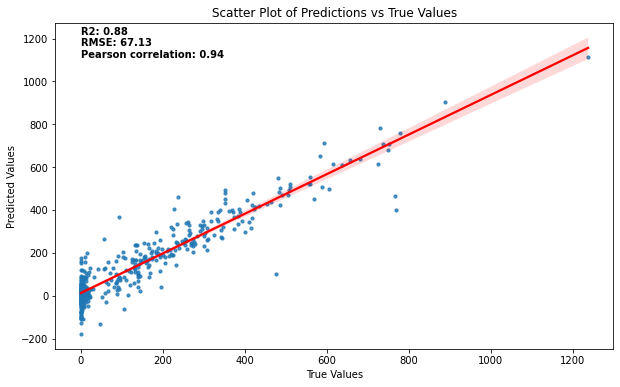

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 绘制散点图并生成拟合直线
# 创建一个图和坐标轴
plt.figure(figsize=(10, 6))
sns.regplot(x=y, y=overall_predictions, scatter_kws={'s':10}, line_kws={"color":"red"})
#sns.regplot(x=y, y=overall_predictions, scatter=False, line_kws={"color":"red"})
#sns.kdeplot(y, overall_predictions, cmap="Blues", shade=True, shade_lowest=False)
#dataframe = pd.DataFrame({'x': y, 'y': overall_predictions})
plot_data = pd.DataFrame({'x': y, 'y': overall_predictions})
#writing to csv
plot_data.to_csv(output_dir+name+'_scatter_plot.csv')

# 计算整体样本的R2和RMSE
overall_r2 = r2_score(y, overall_predictions)
overall_rmse = np.sqrt(mean_squared_error(y, overall_predictions))

# 在图上显示R2和RMSE Pearson correlation pvalue
#plt.text(min(y), max(overall_predictions)-200, f'R2: {overall_r2:.2f}\nRMSE: {overall_rmse:.2f}\nPearson correlation: {overall_correlation:.2f}\nP value: {overall_p_value:.2f}',
#         horizontalalignment='left', size='medium', color='black', weight='semibold')
plt.text(min(y), max(overall_predictions), f'R2: {overall_r2:.2f}\nRMSE: {overall_rmse:.2f}\nPearson correlation: {overall_correlation:.2f}',
         horizontalalignment='left', size='medium', color='black', weight='semibold')

# 设置图表标签和标题
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Scatter Plot of Predictions vs True Values')
#save as pdf
plt.savefig(output_dir+name+'_scatter_plot.pdf')

# 显示图表
plt.show()




In [20]:
mlnc_expression_use_filtered=mlnc_expression_use
X=mlnc_expression_use_filtered.T
y=clin_use["num_group"]
name = "num_group"
Y = y
X = np.asarray(X)
X = np.nan_to_num(X)
y = np.asarray(Y)
min_max_scaler = preprocessing.MinMaxScaler()
X = min_max_scaler.fit_transform(X)
X = np.asarray(X,dtype=np.float32)

In [21]:
model_lists = {
    #'RF':RandomForestClassifier(n_estimators=100, random_state=42),
    #'XGB':xgb.XGBClassifier(n_estimators=100, random_state=42),
    'SVC':SVC(kernel='linear', C=0.01, random_state=42,probability=True,gamma='auto'),
    #'LR':LogisticRegression(random_state=42),
}

In [22]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
results = {
    'Fold': [],
    'train auc': [],
    'test auc': []
}

# 用于存储所有折的真实值、预测概率和折号
true_values = []
predicted_probabilities = []
fold_indices = []

fold = 1
for train_index, test_index in kf.split(X):
    print(f'Fold {fold}')
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    
    # sc = StandardScaler() 
    # sc.fit(X_train) 
    # X_train = sc.transform(X_train) 
    # X_test = sc.transform(X_test) 

    model = LogisticRegression(random_state=42)
    model.fit(X_train, y_train)
    
    y_test_pred_prob = model.predict_proba(X_test)
    y_train_pred_prob = model.predict_proba(X_train)
    train_auc = roc_auc_score(y_train, y_train_pred_prob[:, 1])
    test_auc = roc_auc_score(y_test, y_test_pred_prob[:, 1])
    
    results['Fold'].append(fold)
    results['train auc'].append(train_auc)
    results['test auc'].append(test_auc)

    true_values.extend(y_test)
    predicted_probabilities.extend(y_test_pred_prob[:, 1])
    fold_indices.extend([fold] * len(test_index))
    
    fold += 1

results_df = pd.DataFrame(results)
results_df.to_csv(output_dir+name + '_cross_validation_results.csv', index=False)

# 将所有真实值、预测概率和折号转换为数组
true_values = np.array(true_values)
predicted_probabilities = np.array(predicted_probabilities)
fold_indices = np.array(fold_indices)

# 计算整体样本的auc
overall_auc = roc_auc_score(true_values, predicted_probabilities)

overall_results = {
    'Overall auc': [overall_auc]
}

overall_results_df = pd.DataFrame(overall_results)
overall_results_df.to_csv(output_dir+name + '_overall_results.csv', index=False)

print('Cross-validation results:')
print(results_df)
print('Overall results:')
print(overall_results_df)

print('mean test auc:', results_df['test auc'].mean())

# 合并 y、overall_predictions 和 fold_indices 并保存
y_df = pd.DataFrame(true_values, columns=['true'])
overall_predictions_df = pd.DataFrame(predicted_probabilities, columns=['predicted'])
fold_indices_df = pd.DataFrame(fold_indices, columns=['fold'])
pred_and_true = pd.concat([y_df, overall_predictions_df, fold_indices_df], axis=1)
pred_and_true.index = usesamplename
pred_and_true.to_csv(output_dir+name + '_predicted_and_true.csv')

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9
Fold 10
Cross-validation results:
   Fold  train auc  test auc
0     1   0.998903  0.864444
1     2   0.997421  0.940909
2     3   0.998179  0.903890
3     4   0.997035  0.941176
4     5   0.997208  0.903061
5     6   0.997734  0.915119
6     7   0.997567  0.941176
7     8   0.997115  0.942792
8     9   0.997725  0.945455
9    10   0.997143  0.947368
Overall results:
   Overall auc
0     0.921954
mean test auc: 0.9245391953119


In [128]:
# 显示 pred_and_true DataFrame
print(pred_and_true.head())

         true  predicted  fold
CF-N007     0   0.028802     1
CF-N012     0   0.021276     1
CF-N018     0   0.018367     1
CF-N027     0   0.543094     1
CF-N031     0   0.815809     1


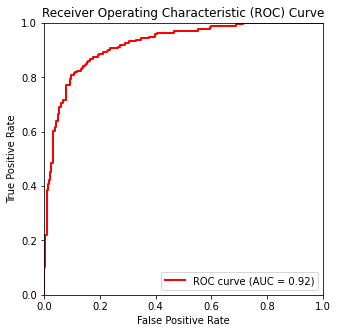

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 从 pred_and_true DataFrame 中提取真实值和预测概率
true_values = pred_and_true['true'].values
predicted_probabilities = pred_and_true['predicted'].values

# 计算 ROC 曲线
fpr, tpr, thresholds = roc_curve(true_values, predicted_probabilities)
roc_auc = auc(fpr, tpr)

# 创建图形
plt.figure(figsize=(5, 5))

# 绘制 ROC 曲线
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 添加标题和标签
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')


# 添加图例
plt.legend(loc='lower right')
# 设置坐标范围
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
#save as pdf
plt.savefig(output_dir+name+'_all_roc_plot.pdf')
# 显示图形
plt.show()

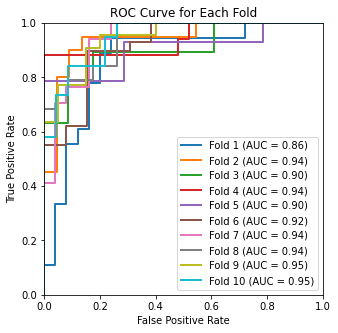

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 读取 pred_and_true DataFrame
pred_and_true = pd.read_csv(output_dir+name + '_predicted_and_true.csv')

# 获取所有折号
folds = pred_and_true['fold'].unique()

# 创建图形
plt.figure(figsize=(5, 5))

# 遍历每个折号，绘制每个折的ROC曲线
for fold in folds:
    fold_data = pred_and_true[pred_and_true['fold'] == fold]
    true_values = fold_data['true'].values
    predicted_probabilities = fold_data['predicted'].values

    # 计算 ROC 曲线
    fpr, tpr, thresholds = roc_curve(true_values, predicted_probabilities)
    roc_auc = auc(fpr, tpr)

    # 绘制 ROC 曲线
    plt.plot(fpr, tpr, lw=2, label=f'Fold {fold} (AUC = {roc_auc:.2f})')


# 添加标题和标签
plt.title('ROC Curve for Each Fold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# 添加图例
plt.legend(loc='lower right')

# 设置坐标范围
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
#save as pdf
plt.savefig(output_dir+name+'_10fold_roc_plot.pdf')
# 显示图形
plt.show()